# Notebook 2 — Comparative Genomics

Analysis of the **SLC26 anion transporter family** across 30 mammalian
species.

Topics:
1. **NCBI taxonomy database**
2. **Gene family tree** visualization
3. **Phylogenetic profiles**
4. **Prestin (SLC26A5)** alignment — cochlear motor protein
5. Measure **sequence conservation** with Shannon entropy

---
## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math

sns.set_theme()

DATA = os.path.join('..', 'data')
SUB_DIR = os.path.join(DATA, 'subfamilies')

In [2]:
def read_fasta(path):
    """Read a FASTA file → dict of {header: sequence}."""
    seqs = {}
    header = None
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                header = line[1:].split()[0]
                seqs[header] = ''
            elif header:
                seqs[header] += line
    return seqs

---
## 2. The NCBI Taxonomy Database

The [NCBI Taxonomy](https://www.ncbi.nlm.nih.gov/taxonomy) is a curated
classification of all organisms with sequences in GenBank. ETE4 provides
a Python interface to query it locally.

This is useful because our sequence headers contain **taxids** (taxonomy IDs)
like `9606` for *Homo sapiens* — we need to convert those into species
names, lineages, and phylogenetic relationships.

In [3]:
from ete4 import NCBITaxa

ncbi = NCBITaxa()

### 2.1 Basic queries

In [4]:
# Convert a taxid to a species name
taxid2name = ncbi.get_taxid_translator([9606])
print(f"Taxid 9606 -> {taxid2name[9606]}")

Taxid 9606 -> Homo sapiens


In [5]:
# Get the full lineage of a species
lineage = ncbi.get_lineage(9606)
lineage_names = ncbi.get_taxid_translator(lineage)
print("Lineage of Homo sapiens:")
for tid in lineage:
    print(f"  {tid:>10d}  {lineage_names[tid]}")

Lineage of Homo sapiens:
           1  root
      131567  cellular organisms
        2759  Eukaryota
       33154  Opisthokonta
       33208  Metazoa
        6072  Eumetazoa
       33213  Bilateria
       33511  Deuterostomia
        7711  Chordata
       89593  Craniata
        7742  Vertebrata
        7776  Gnathostomata
      117570  Teleostomi
      117571  Euteleostomi
        8287  Sarcopterygii
     1338369  Dipnotetrapodomorpha
       32523  Tetrapoda
       32524  Amniota
       40674  Mammalia
       32525  Theria
        9347  Eutheria
     1437010  Boreoeutheria
      314146  Euarchontoglires
        9443  Primates
      376913  Haplorrhini
      314293  Simiiformes
        9526  Catarrhini
      314295  Hominoidea
        9604  Hominidae
      207598  Homininae
        9605  Homo
        9606  Homo sapiens


In [6]:
# Get the taxonomic rank of each level
ranks = ncbi.get_rank(lineage)
print("\nRanks:")
for tid in lineage:
    print(f"  {lineage_names[tid]:<30s}  {ranks[tid]}")


Ranks:
  root                            no rank
  cellular organisms              no rank
  Eukaryota                       domain
  Opisthokonta                    clade
  Metazoa                         kingdom
  Eumetazoa                       clade
  Bilateria                       clade
  Deuterostomia                   clade
  Chordata                        phylum
  Craniata                        subphylum
  Vertebrata                      clade
  Gnathostomata                   clade
  Teleostomi                      clade
  Euteleostomi                    clade
  Sarcopterygii                   superclass
  Dipnotetrapodomorpha            clade
  Tetrapoda                       clade
  Amniota                         clade
  Mammalia                        class
  Theria                          clade
  Eutheria                        clade
  Boreoeutheria                   clade
  Euarchontoglires                superorder
  Primates                        order
  Haplorrh

### 2.2 Topology based on NCBI taxonomy

In [42]:
# Get the NCBI species tree for a set of taxids
some_taxids = [9606, 10090, 9739, 59479, 9913]  # human, mouse, dolphin, horseshoe bat, cow
species_tree = ncbi.get_topology(some_taxids)

# Annotate with scientific names
ncbi.annotate_tree(species_tree)

print(species_tree.to_str(props=['sci_name']))

                                  ╭╴Homo sapiens
               ╭╴Euarchontoglires╶┤
               │                  ╰╴Mus musculus
╴Boreoeutheria╶┤
               │                               ╭╴Tursiops truncatus
               │                ╭╴Artiodactyla╶┤
               ╰╴Laurasiatheria╶┤              ╰╴Bos taurus
                                │
                                ╰╴Rhinolophus ferrumequinum


### Exercise 1

1. Find the taxonomy of the **bottlenose dolphin** (*Tursiops truncatus*,
   taxid 9739). What **order** does it belong to?

2. Look up a bat, say *Myotis lucifugus* (taxid 59463). What order?

3. Both dolphins and bats echolocate, but they are in completely different
   orders. What is the most recent common ancestor of these two species
   according to the NCBI tree? *(build a tree with `get_topology`
   for just those two taxids and look at the root.)*

In [8]:
# Your code here

---
## 3. The SLC26 gene family tree

In Lesson 1 we built a tree of all ~297 SLC26 sequences. Let's reload
it and annotate with taxonomy and evolution events.

In [44]:
from ete4 import PhyloTree
from ete4.smartview import Layout, TextFace, RectFace

FAMILY_TREE = os.path.join(DATA, 'selection2.clustalo.gt01.fasttree.nwk')

t = PhyloTree(open(FAMILY_TREE).read(),
              sp_naming_function=lambda n: n.split('.')[0])
t.set_outgroup(t.get_midpoint_outgroup())

#t.resolve_polytomy(descendants=True)

print("Annotating with NCBI taxonomy...")
t.annotate_ncbi_taxa()

print("Inferring duplication/speciation events...")
events = t.get_descendant_evol_events()

n_dup = sum(1 for e in events if e.etype == 'D')
n_spec = sum(1 for e in events if e.etype == 'S')
print(f"  Leaves: {len(list(t.leaves()))}")
print(f"  Duplication events: {n_dup}")
print(f"  Speciation events: {n_spec}")

Annotating with NCBI taxonomy...
Inferring duplication/speciation events...
  Leaves: 297
  Duplication events: 13
  Speciation events: 283


### 3.1 Understanding orthology and paralogy

The tree contains two types of events:
- **Speciation** events: where a gene was inherited by two daughter species
  (genes connected by speciation = **orthologs**)
- **Duplication** events: where a gene was copied within a genome
  (genes connected by duplication = **paralogs**)

The SLC26 family arose through ~10 ancient duplication events, creating
subfamilies A1 through A11. Within each subfamily, all genes are orthologs.

### 3.2 Loading subfamily assignments

In [45]:
# Load gene name mapping
GNAME_FILE = os.path.join(DATA, 'selection2.clustalo.seqid2gname.tab')
seqid2gene = {}
if os.path.exists(GNAME_FILE):
    for line in open(GNAME_FILE):
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            seqid2gene[parts[0]] = parts[1]
    print(f"Loaded {len(seqid2gene)} gene name mappings")

import re

def guess_subfamily(gene_name):
    if not gene_name:
        return 'unknown'
    text = gene_name.upper()
    m = re.search(r'S(?:LC)?26A(\d+)', text)
    if m:
        return f"SLC26A{m.group(1)}"
    if 'PRESTIN' in text:
        return 'SLC26A5'
    if 'PENDRIN' in text:
        return 'SLC26A4'
    return 'unknown'

# Assign subfamily to each leaf
for leaf in t.leaves():
    gname = seqid2gene.get(leaf.name, '')
    leaf.add_prop('gene_name', gname)
    leaf.add_prop('subfamily', guess_subfamily(gname))

# Summary
sub_counts = Counter(leaf.props.get('subfamily') for leaf in t.leaves())
print(f"\n{'Subfamily':<15s} {'Count':>6s}")
print('-' * 25)
for sub, count in sorted(sub_counts.items()):
    print(f"  {sub:<15s} {count:>4d}")

Loaded 297 gene name mappings

Subfamily        Count
-------------------------
  SLC26A1           19
  SLC26A10          15
  SLC26A11          21
  SLC26A2           22
  SLC26A3           20
  SLC26A4           20
  SLC26A5           21
  SLC26A6           17
  SLC26A7           20
  SLC26A8           22
  SLC26A9           20
  unknown           80


### 3.3 Visualize the family tree with subfamilies colored

In [47]:
SUBFAMILY_COLORS = {
    'SLC26A1':  '#5DCAA5',
    'SLC26A2':  '#1D9E75',
    'SLC26A3':  '#85B7EB',
    'SLC26A4':  '#F0997B',
    'SLC26A5':  '#D85A30',   # prestin — the key gene
    'SLC26A6':  '#378ADD',
    'SLC26A7':  '#97C459',
    'SLC26A8':  '#ED93B1',
    'SLC26A9':  '#AFA9EC',
    'SLC26A11': '#EF9F27',
    'unknown':  '#CCCCCC',
}

def subfamily_layout(node):
    if not node.is_leaf:
        # Mark duplication events
        if node.props.get('evoltype') == 'D':
            return {'dot': {'shape': 'circle', 'radius': 8, 'fill': 'red'}}
        return

    sub = node.props.get('subfamily', 'unknown')
    color = SUBFAMILY_COLORS.get(sub, '#CCCCCC')
    sci = node.props.get('sci_name', '')
    gname = node.props.get('gene_name', '')
    label = f"{sci} ({gname})" if gname else sci

    return [
        TextFace(label, style={'fill': 'black'},
                 column=0, position='aligned'),
        {'box': {'fill': color}}
    ]

tree_style = {'node-height-min': 1, 'smart-zoom': False}

layouts = [
    Layout(name='TreeStyle', draw_tree=tree_style, active=True),
    Layout(name='Subfamilies', draw_node=subfamily_layout, active=True),
]

print("Launching tree viewer — look for colored subfamily clades")
print("Red squares at internal nodes = gene duplication events")
t.explore(layouts=layouts, keep_server=False, show_leaf_name=False,
          name='SLC26 family')

Launching tree viewer — look for colored subfamily clades
Red squares at internal nodes = gene duplication events
Using existing server.
Explorer available at http://127.0.0.1:5002


### ✏️ Exercise 2

In the tree viewer:
1. How many distinct subfamily clades can you identify?
2. Which subfamilies are **sister clades** (most closely related)?
3. Find the **prestin (SLC26A5)** clade (coral/orange). How many
   leaves does it have? Is that roughly one per species?
4. Are there any subfamilies where some species have **more than one**
   copy? (Look for lineage-specific duplications within a clade.)

---
## 4. Phylogenetic profile

A **phylogenetic profile** shows which species have which genes.
We display it as a grid on the NCBI species tree: one column per
subfamily, one row per species, colored if the gene is present.

### 4.1 Build the profile table

In [48]:
# Count how many copies each species has per subfamily
profile = {}
for leaf in t.leaves():
    taxid = leaf.name.split('.')[0]
    sub = leaf.props.get('subfamily', 'unknown')
    if sub == 'unknown':
        continue
    key = (taxid, sub)
    profile[key] = profile.get(key, 0) + 1

# Unique taxids and subfamilies
all_taxids = sorted(set(k[0] for k in profile))
all_subs = sorted(set(k[1] for k in profile),
                  key=lambda s: int(re.search(r'\d+', s).group()) if re.search(r'\d+', s) else 99)

# Build DataFrame
profile_df = pd.DataFrame(0, index=all_taxids, columns=all_subs)
for (taxid, sub), count in profile.items():
    profile_df.loc[taxid, sub] = count

# Add species names
taxid2name_map = ncbi.get_taxid_translator([int(t) for t in all_taxids])
profile_df.index = [f"{taxid2name_map.get(int(t), t)}" for t in profile_df.index]

# Keep a copy with taxids for the ETE4 visualization
profile_taxid = pd.DataFrame(0, index=all_taxids, columns=all_subs)
for (taxid, sub), count in profile.items():
    profile_taxid.loc[taxid, sub] = count

print(profile_df)

                           SLC26A5  SLC26A6  SLC26A8  SLC26A1  SLC26A3  \
Mus musculus                     1        1        1        1        1   
Lipotes vexillifer               1        1        1        1        1   
Pteropus vampyrus                1        1        1        1        1   
Monodelphis domestica            1        1        1        1        1   
Hipposideros armiger             1        1        1        1        1   
Vombatus ursinus                 1        1        1        1        1   
Callorhinus ursinus              1        1        1        1        0   
Phascolarctos cinereus           1        1        1        1        1   
Myotis lucifugus                 1        0        1        0        1   
Rhinolophus ferrumequinum        1        1        1        1        1   
Phyllostomus discolor            1        0        1        0        1   
Sarcophilus harrisii             1        1        1        1        1   
Homo sapiens                     1    

### 4.2 Visualize on the NCBI species tree

In [49]:
# Build NCBI species tree for our taxids
species_tree = ncbi.get_topology([int(t) for t in all_taxids])
ncbi.annotate_tree(species_tree)

# Attach profile data to leaves
for leaf in species_tree.leaves():
    taxid = str(leaf.taxid)
    for sub in all_subs:
        count = int(profile_taxid.loc[taxid, sub]) if taxid in profile_taxid.index else 0
        leaf.add_prop(f'n_{sub}', count)

In [54]:
# Layout: phylogenetic profile as colored rectangles
def profile_layout(node):
    if not node.is_leaf:
        return
    faces = []
    # One rectangle per subfamily
    for i, sub in enumerate(all_subs):
        count = node.props.get(f'n_{sub}', 0)
        if count > 0:
            color = SUBFAMILY_COLORS.get(sub, '#CCCCCC')
            label = str(count) if count > 0 else ''
            faces.append(RectFace(wmax=20, hmax=20, style={'fill': color},
                                  text=label,
                                  column=i + 1, position='aligned'))
        else:
            faces.append(RectFace(wmax=20, hmax=20, style={'fill': '#F5F5F5'},
                                  column=i + 1, position='aligned'))
    return faces

# Header: subfamily names
def profile_header(tree):
    faces = []
    for i, sub in enumerate(all_subs):
        color = SUBFAMILY_COLORS.get(sub, '#CCCCCC')
        short = sub.replace('SLC26', '')
        faces.append(TextFace(short, column=i + 1, position='header',
                              rotation=-90,
                              style={'fill': color, 'font-size': '10px'}))
    return faces

def node_names_style(node):
    if node.is_leaf:
        acc = node.name.split(".")[1] if "." in node.name else node.name
        sci = node.props.get("sci_name", "")
        return [
            TextFace(f"{sci}", style={"fill": "gray"}, column=0, position="right"),
        ]

profile_tree_style = {'node-height-min': 15, 'smart-zoom': False}

profile_layouts = [
    Layout(name="Names", draw_node=node_names_style, active=True),
    Layout(name='ProfileStyle', draw_tree=profile_tree_style, active=True),
    Layout(name='Profile', draw_node=profile_layout, draw_tree=profile_header, active=True),
]

species_tree.to_ultrametric()

print("Launching phylogenetic profile viewer...")
species_tree.explore(layouts=profile_layouts, keep_server=False,
                     show_leaf_name=False, name='SLC26 phylogenetic profile')

Launching phylogenetic profile viewer...
Using existing server.
Explorer available at http://127.0.0.1:5002


### ✏️ Exercise 3

From the phylogenetic profile:
1. Do all species have all subfamilies? Which species have **fewer**
   genes than expected?
2. Is there any subfamily that's missing from multiple species?
3. Do the **echolocating** species (dolphins, bats) have any unusual
   pattern in their SLC26 gene complement?

---
## 5. The prestin (SLC26A5) sub-alignment

From the family tree, we extracted the prestin clade — one ortholog
per species — and re-aligned them with MAFFT, then trimmed. Let's
visualize the alignment and the prestin tree.

### 5.1 Visualize with pyMSAviz

Using -gt 0.99 trimmed alignment: ../data/subfamilies/SLC26A5.trim099.fa


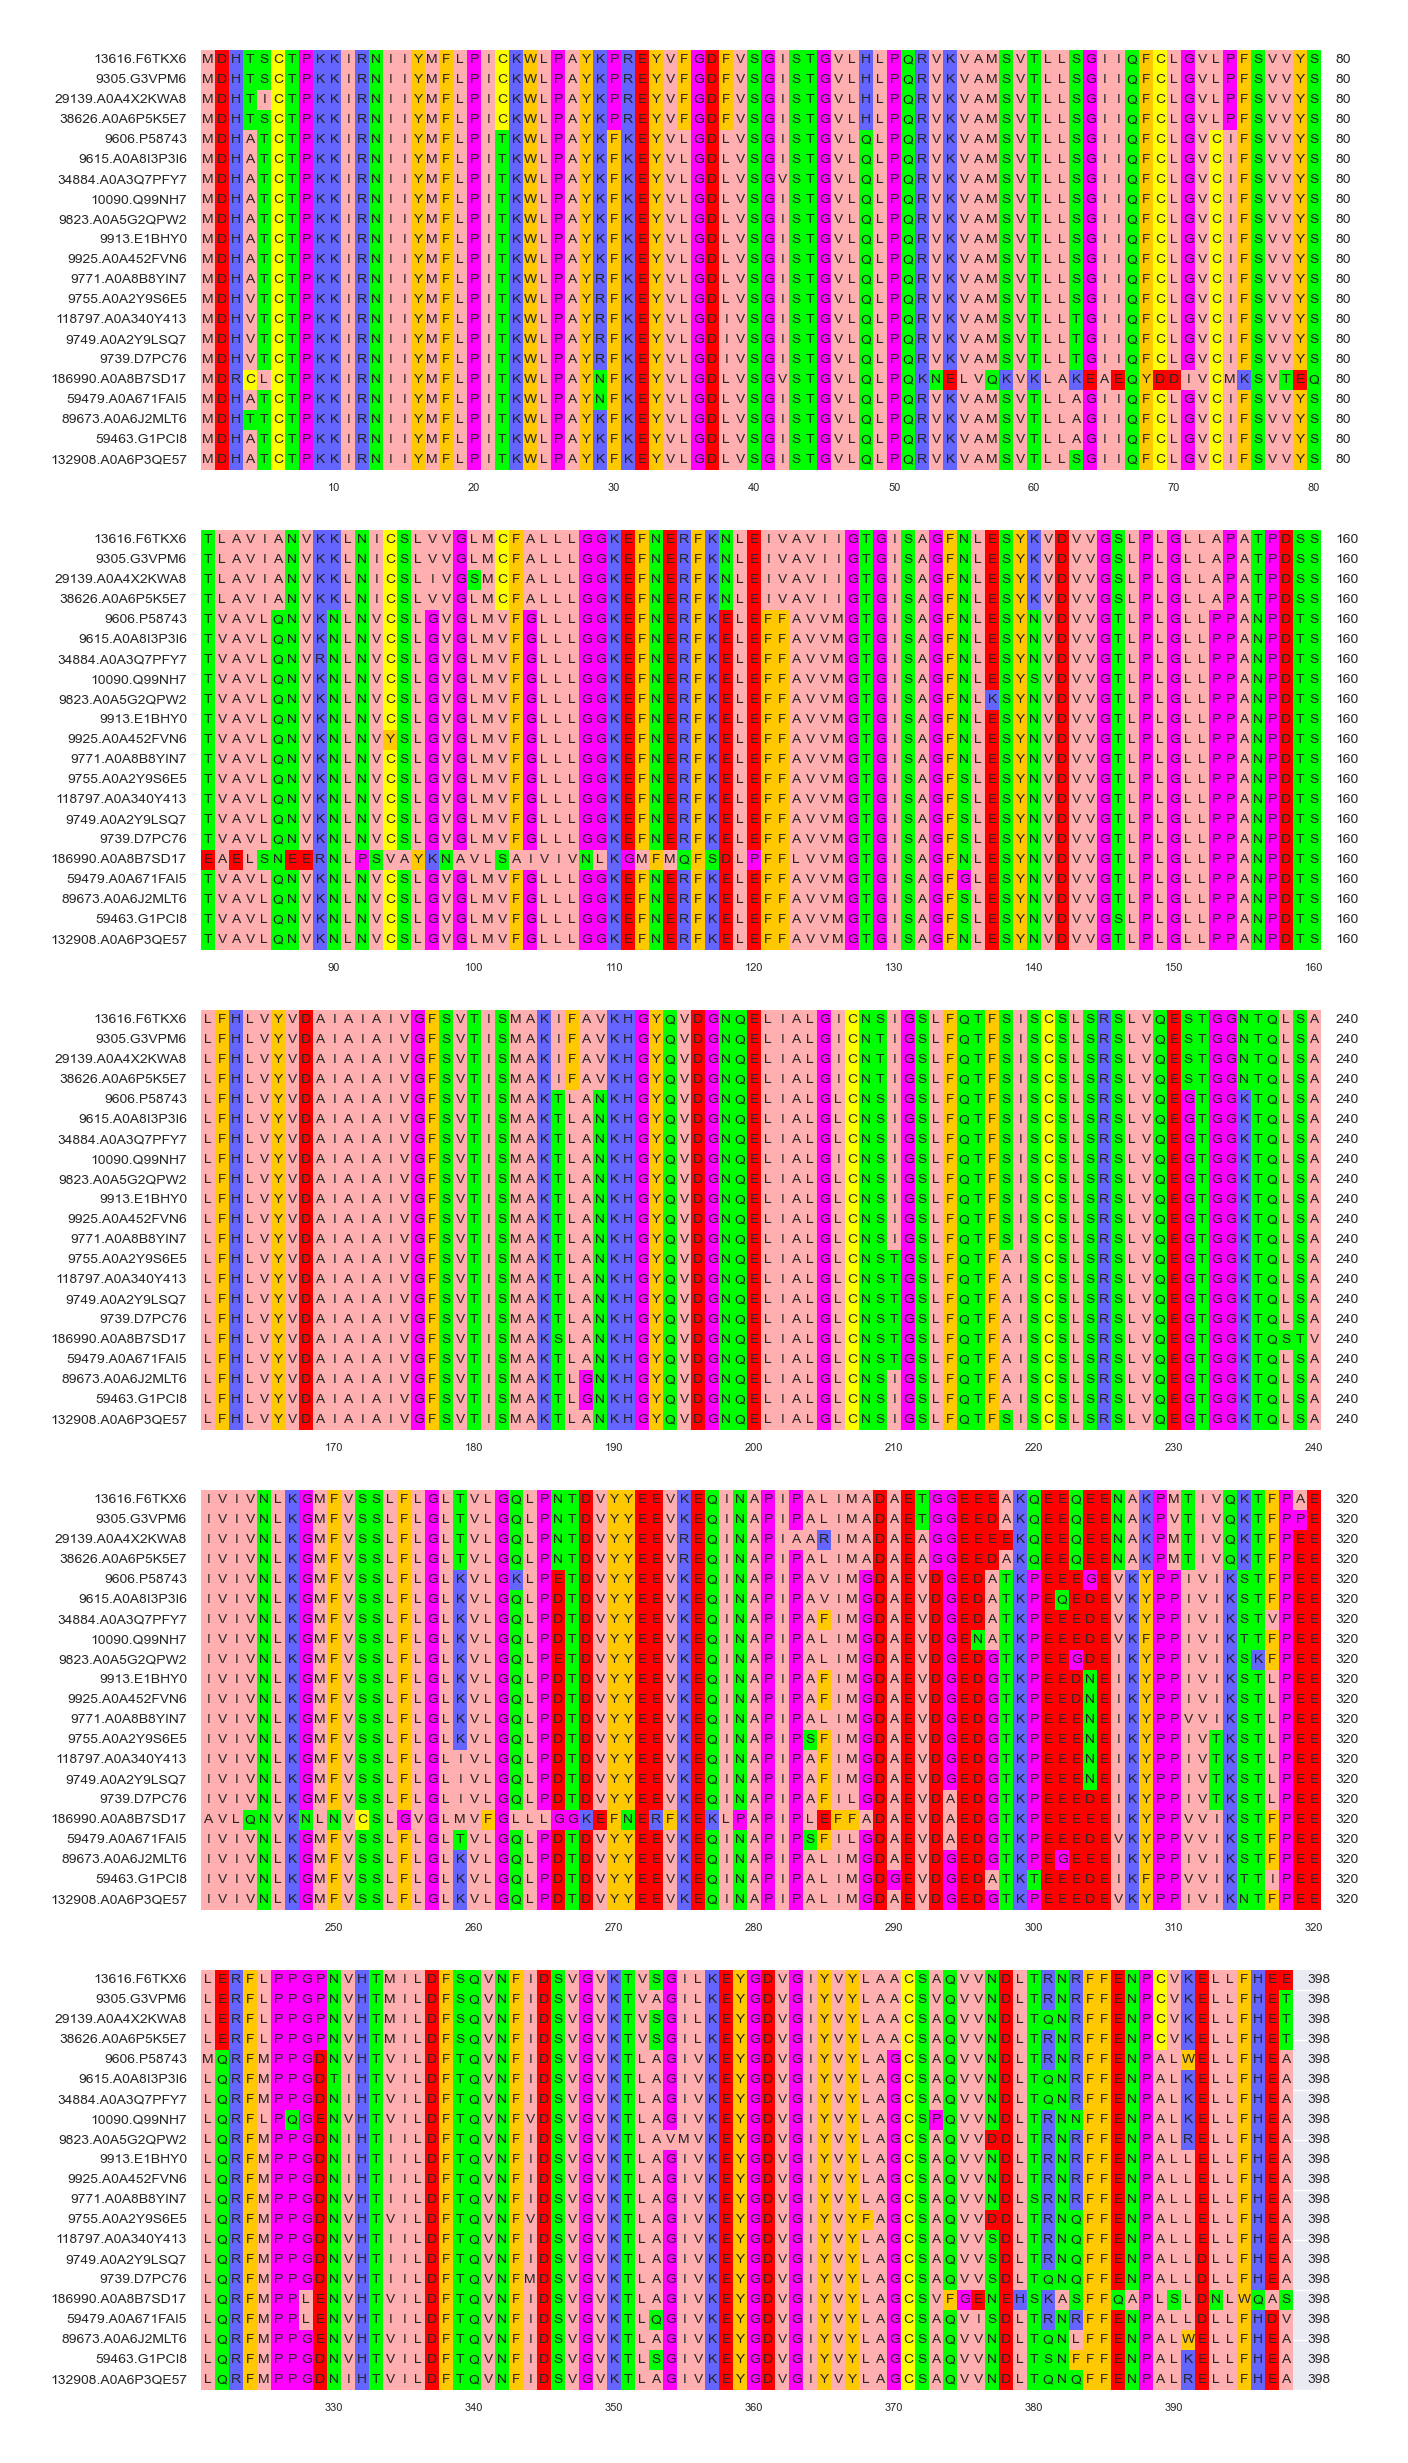

In [59]:
from pymsaviz import MsaViz

# Use the heavily trimmed alignment for cleaner visualization
PRESTIN_VIZ = os.path.join(SUB_DIR, 'SLC26A5.trim099.fa')
if not os.path.exists(PRESTIN_VIZ):
    # Fall back to lighter trimming
    PRESTIN_VIZ = os.path.join(SUB_DIR, 'SLC26A5.trim.fa')
    print(f"Using -gt 0.1 trimmed alignment: {PRESTIN_VIZ}")
else:
    print(f"Using -gt 0.99 trimmed alignment: {PRESTIN_VIZ}")

mv = MsaViz(PRESTIN_VIZ, wrap_length=80, show_count=True)
fig = mv.plotfig()
plt.show()

### 5.2 Prestin tree with echolocators highlighted

In [60]:
# Load species classification
species_df = pd.read_csv(
    os.path.join(DATA, 'species_classification.tsv'),
    sep='\t', comment='#',
    names=['taxid', 'species', 'group', 'echolocates', 'notes']
)
species_df['taxid'] = species_df['taxid'].astype(str)

echo_lookup = dict(zip(species_df['taxid'], species_df['echolocates']))
name_lookup = dict(zip(species_df['taxid'], species_df['species']))
group_lookup = dict(zip(species_df['taxid'], species_df['group']))

In [66]:
PRESTIN_TREE = os.path.join(SUB_DIR, 'SLC26A5.nwk')
pt = PhyloTree(open(PRESTIN_TREE).read(),
               sp_naming_function=lambda n: n.split('.')[0])
# pt.set_outgroup(pt.get_midpoint_outgroup())
pt.set_outgroup(pt.common_ancestor(['13616.F6TKX6', '38626.A0A6P5K5E7']))

pt.annotate_ncbi_taxa()

ECHO_COLORS = {
    'echolocating_bat':         '#D85A30',
    'echolocating_cetacean':    '#1D9E75',
    'non_echolocating_bat':     '#7F77DD',
    'non_echolocating_cetacean':'#378ADD',
    'outgroup':                 '#888888',
}

def prestin_echo_layout(node):
    if not node.is_leaf:
        return
    taxid = node.name.split('.')[0]
    sci = node.props.get('sci_name', taxid)
    group = group_lookup.get(taxid, 'outgroup')
    echo = echo_lookup.get(taxid, 'no')
    color = ECHO_COLORS.get(group, '#888888')
    marker = '  ᯤ' if echo == 'yes' else ''

    return [
        TextFace(f"{sci}{marker}",
                 style={'fill': color,
                        'font-weight': 'bold' if echo == 'yes' else 'normal'},
                 column=0, position='right'),
    ]

pt_style = {'node-height-min': 1, 'smart-zoom': False}

pt.explore(
    layouts=[
        Layout(name='Style', draw_tree=pt_style),
        Layout(name='Echolocation', draw_node=prestin_echo_layout),
    ],
    keep_server=False, show_leaf_name=False, name='Prestin tree'
)

Using existing server.
Explorer available at http://127.0.0.1:5002


### ✏️ Exercise 4

Look at the prestin tree:
1. Do the echolocating species (coral = bats, teal = dolphins) form
   a **single clade**, or are they scattered across the tree?
2. Does the tree mostly follow the **species phylogeny** (e.g., are
   all bats together, all cetaceans together)?
3. What does this tell you about convergent evolution at the **tree
   topology** level vs. at the **individual amino acid** level?

---
## 6. Working with alignment data in pandas

Let's convert the prestin alignment into a pandas DataFrame so we can
analyze it as a table.

In [67]:
# Load the analysis-level alignment (lighter trim)
PRESTIN_ALN = os.path.join(SUB_DIR, 'SLC26A5.trim.fa')
prestin = read_fasta(PRESTIN_ALN)

print(f"Sequences:        {len(prestin)}")
print(f"Alignment length: {len(list(prestin.values())[0])} positions")

Sequences:        21
Alignment length: 750 positions


### 6.1 Creating a DataFrame from the alignment

In [68]:
headers = list(prestin.keys())
matrix = [list(seq) for seq in prestin.values()]

aln = pd.DataFrame(matrix, index=headers)
aln.columns.name = 'position'

print(f"Shape: {aln.shape}")
print(f"  → {aln.shape[0]} rows (sequences / species)")
print(f"  → {aln.shape[1]} columns (alignment positions)")

Shape: (21, 750)
  → 21 rows (sequences / species)
  → 750 columns (alignment positions)


In [69]:
aln.head(3)

position,0,1,2,3,4,5,6,7,8,9,...,740,741,742,743,744,745,746,747,748,749
13616.F6TKX6,M,D,H,T,Q,E,N,E,I,L,...,P,I,A,D,P,-,-,-,E,E
9305.G3VPM6,M,D,H,T,Q,E,N,E,I,L,...,P,I,I,D,P,-,-,-,E,T
29139.A0A4X2KWA8,M,D,H,T,Q,E,N,E,I,L,...,P,I,V,D,P,-,-,-,E,T


### 6.2 Selecting data in pandas

pandas gives you many ways to select parts of a table.

In [70]:
# Select a single column → one alignment position
# This returns a "Series" — like a labeled list
aln[0]

13616.F6TKX6         M
9305.G3VPM6          M
29139.A0A4X2KWA8     M
38626.A0A6P5K5E7     M
9606.P58743          M
9615.A0A8I3P3I6      M
34884.A0A3Q7PFY7     M
10090.Q99NH7         M
9823.A0A5G2QPW2      M
9913.E1BHY0          M
9925.A0A452FVN6      M
9771.A0A8B8YIN7      M
9755.A0A2Y9S6E5      M
118797.A0A340Y413    M
9749.A0A2Y9LSQ7      M
9739.D7PC76          M
186990.A0A8B7SD17    M
59479.A0A671FAI5     M
89673.A0A6J2MLT6     M
59463.G1PCI8         M
132908.A0A6P3QE57    M
Name: 0, dtype: str

In [71]:
# Count amino acids at position 0
aln[0].value_counts()

0
M    21
Name: count, dtype: int64

In [72]:
# Select a range of columns
aln[[50, 51, 52, 53, 54]]

position,50,51,52,53,54
13616.F6TKX6,S,C,T,P,K
9305.G3VPM6,S,C,T,P,K
29139.A0A4X2KWA8,I,C,T,P,K
38626.A0A6P5K5E7,S,C,T,P,K
9606.P58743,T,C,T,P,K
9615.A0A8I3P3I6,T,C,T,P,K
34884.A0A3Q7PFY7,T,C,T,P,K
10090.Q99NH7,T,C,T,P,K
9823.A0A5G2QPW2,T,C,T,P,K
9913.E1BHY0,T,C,T,P,K


In [73]:
# Select a single row by position number (0-based)
aln.iloc[0]

position
0      M
1      D
2      H
3      T
4      Q
      ..
745    -
746    -
747    -
748    E
749    E
Name: 13616.F6TKX6, Length: 750, dtype: str

In [74]:
# Select a row by its label (header name)
first_header = aln.index[0]
aln.loc[first_header]

position
0      M
1      D
2      H
3      T
4      Q
      ..
745    -
746    -
747    -
748    E
749    E
Name: 13616.F6TKX6, Length: 750, dtype: str

### 6.3 Boolean indexing — selecting by condition

One of the most powerful pandas features: pick rows where a condition
is True.

In [75]:
# Build a True/False series: is this species an echolocator?
taxids = [h.split('.')[0] for h in aln.index]
is_echo = pd.Series(
    [echo_lookup.get(t) == 'yes' for t in taxids],
    index=aln.index
)

print(f"Echolocating species:     {is_echo.sum()}")
print(f"Non-echolocating species: {(~is_echo).sum()}")

Echolocating species:     8
Non-echolocating species: 13


In [76]:
# Select only echolocator rows
echo_aln = aln[is_echo]
echo_aln.head()

position,0,1,2,3,4,5,6,7,8,9,...,740,741,742,743,744,745,746,747,748,749
9755.A0A2Y9S6E5,M,D,H,V,E,E,N,E,I,L,...,P,N,A,T,P,-,-,-,E,A
118797.A0A340Y413,M,D,H,V,E,E,S,E,I,L,...,P,N,A,T,P,-,-,-,E,A
9749.A0A2Y9LSQ7,M,D,H,V,E,E,S,E,I,L,...,P,N,A,T,P,-,-,-,E,A
9739.D7PC76,M,D,H,V,E,E,T,E,I,L,...,P,N,A,T,P,-,-,-,E,A
186990.A0A8B7SD17,M,D,R,C,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,A,S


In [28]:
# The tilde ~ means NOT — select non-echolocators
other_aln = aln[~is_echo]
other_aln.head()

position,0,1,2,3,4,5,6,7,8,9,...,740,741,742,743,744,745,746,747,748,749
13616.F6TKX6,M,D,H,T,Q,E,N,E,I,L,...,P,I,A,D,P,-,-,-,E,E
9305.G3VPM6,M,D,H,T,Q,E,N,E,I,L,...,P,I,I,D,P,-,-,-,E,T
29139.A0A4X2KWA8,M,D,H,T,Q,E,N,E,I,L,...,P,I,V,D,P,-,-,-,E,T
38626.A0A6P5K5E7,M,D,H,T,Q,E,N,E,I,L,...,P,I,T,D,P,-,-,-,E,T
9606.P58743,M,D,H,A,E,E,N,E,I,L,...,P,N,A,T,P,A,T,P,E,A


### ✏️ Exercise 5

1. Pick a few alignment positions and compare amino acids between
   echolocators and non-echolocators using `value_counts()`.
2. Can you find a position where echolocators **mostly agree** on
   one amino acid, but non-echolocators are more diverse?
3. How would you compute the **gap fraction** at a given position?
   *(Hint: count how many entries equal `'-'`, divide by total.)*

In [29]:
# Your code here

---
## 7. Shannon entropy — measuring conservation

### 7.1 The idea

Some alignment positions are **conserved** (every species has the same
amino acid) while others are **variable**. We want a number that
captures this.

**Shannon entropy** comes from **information theory** (Claude Shannon,
1948). Originally it measured the information content of messages —
how "surprising" or "unpredictable" a signal is. A perfectly
predictable signal (always the same letter) has entropy 0. A maximally
unpredictable one (all letters equally likely) has maximum entropy.

The same idea applies to alignment positions: a conserved position is
"predictable" (low entropy), a variable one is "surprising" (high
entropy).

### 7.2 The formula

$$H = -\sum_{i=1}^{k} p_i \cdot \log_2(p_i)$$

where $p_i$ is the frequency of amino acid $i$ at that position, and
$k$ is the number of distinct amino acids observed.

**Why $\log_2$?** Because Shannon originally measured information in
**bits**. One bit = one yes/no question. If a position has 2 equally
likely amino acids, you need 1 bit (one yes/no question) to identify
which one → $H = 1.0$.

**Why the minus sign?** Because $\log_2(p) < 0$ when $p < 1$, and we
want entropy to be positive.

**Boundary cases:**
- Perfectly conserved: $p = 1$ for one amino acid → $H = -1 \cdot \log_2(1) = 0$
- Two amino acids at 50/50: $H = -2 \times (0.5 \cdot \log_2(0.5)) = 1.0$ bit
- All 20 amino acids equally: $H = \log_2(20) \approx 4.32$ bits

### 7.3 Computing entropy step by step

In [30]:
# Let's compute entropy at position 100 by hand
col = list(aln[100])

# Remove gaps
residues = [aa for aa in col if aa != '-']
print(f"Position 100: {len(residues)} residues (no gaps)")

# Count each amino acid
counts = Counter(residues)
total = len(residues)
print(f"Counts: {dict(counts)}")
print()

# Compute frequencies and entropy contributions
entropy = 0.0
for aa, count in counts.items():
    p = count / total
    contribution = -p * math.log2(p)
    entropy += contribution
    print(f"  {aa}: p = {count}/{total} = {p:.3f}"
          f"  →  -p·log₂(p) = {contribution:.4f}")

print(f"\nShannon entropy at position 100: {entropy:.3f} bits")

Position 100: 19 residues (no gaps)
Counts: {'F': 19}

  F: p = 19/19 = 1.000  →  -p·log₂(p) = -0.0000

Shannon entropy at position 100: 0.000 bits


### ✏️ Exercise 6

Now it's your turn. **Write a function** that computes Shannon entropy
for a list of amino acids (ignoring gaps):

```python
def shannon_entropy(column):
    """Shannon entropy of a list of amino acids (ignoring gaps)."""
    # 1. Remove gaps
    # 2. Count each amino acid
    # 3. Compute frequencies
    # 4. Apply the formula: H = -Σ p·log₂(p)
    # 5. Return H
    pass
```

Test your function:
- All same amino acid → should return 0.0
- Half A, half G → should return 1.0
- Position 100 → should match our calculation above

In [31]:
def shannon_entropy(column):
    """Shannon entropy of a list of amino acids (ignoring gaps)."""
    # YOUR CODE HERE
    pass

In [32]:
# Test it
# print(shannon_entropy(['A', 'A', 'A', 'A']))          # → 0.0
# print(shannon_entropy(['A', 'G', 'A', 'G']))          # → 1.0
# print(shannon_entropy(list(aln[100])))                 # → should match above

### 7.4 Solution

In [78]:
# 

### 7.5 Conservation profile across the whole alignment

In [34]:
n_pos = aln.shape[1]
entropies = [shannon_entropy(list(aln[pos])) for pos in range(n_pos)]

print(f"Computed entropy for {n_pos} positions")
print(f"  Min: {min(entropies):.3f}  (most conserved)")
print(f"  Max: {max(entropies):.3f}  (most variable)")
print(f"  Mean: {np.mean(entropies):.3f}")

Computed entropy for 750 positions
  Min: 0.000  (most conserved)
  Max: 2.204  (most variable)
  Mean: 0.261


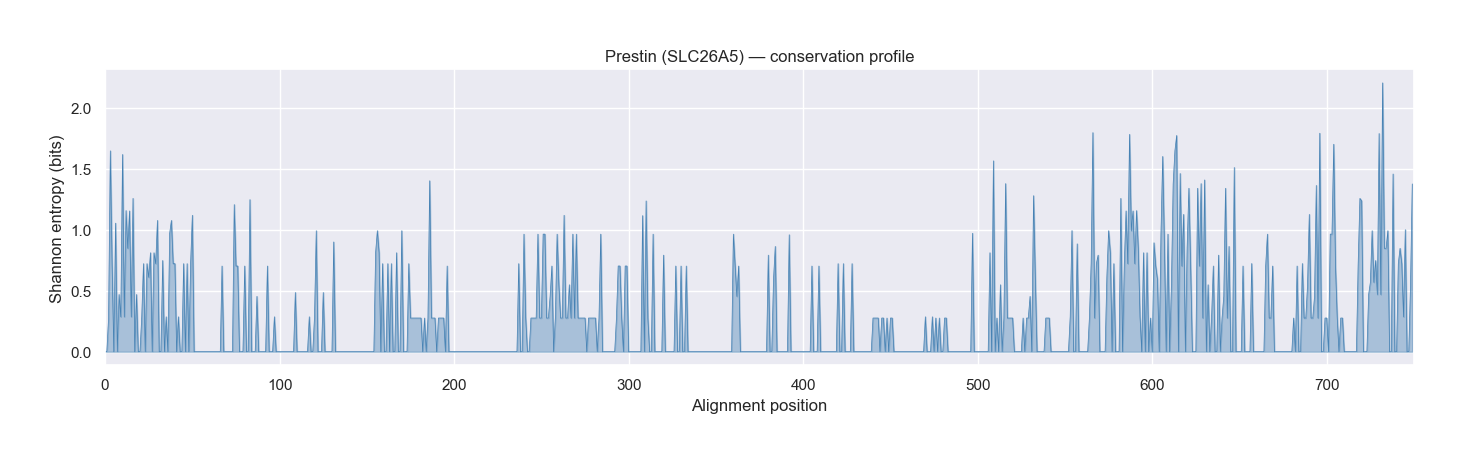

In [35]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(n_pos), entropies, alpha=0.4, color='steelblue')
ax.plot(range(n_pos), entropies, linewidth=0.5, color='steelblue')
ax.set_xlabel('Alignment position')
ax.set_ylabel('Shannon entropy (bits)')
ax.set_title('Prestin (SLC26A5) — conservation profile')
ax.set_xlim(0, n_pos)
plt.tight_layout()
plt.show()

Valleys = highly conserved regions. Peaks = variable regions.

### ✏️ Exercise 7

1. How many positions have entropy = 0 (perfectly conserved)?
   What fraction of the alignment is that?

2. What are the 10 **most conserved** positions with non-zero entropy?
   What amino acids are at those positions?

3. What are the 10 **most variable** positions? Are they near the
   beginning/end of the alignment (where trimming may be imperfect)?

4. Compute the **mean entropy** separately for echolocators and
   non-echolocators. Is the prestin protein more or less conserved
   in echolocators?

In [36]:
# Your code here

---
## 8. Structure visualization with PyMOL

Human prestin has cryo-EM structures available (PDB: **7S8X**,
Bavi et al. 2021). We can map our most conserved positions onto
the 3D structure to see where they are.

You can also explore prestin on UniProt:
https://www.uniprot.org/uniprotkb/P58743/entry#structure

### Installation

```bash
conda install conda-forge::pymol-open-source
```

### 8.1 Map alignment positions to sequence positions

The entropy values are in **alignment coordinates** (which include
gaps). To place them on the structure, we need the position in the
**ungapped human sequence**.

In [37]:
# Find the human prestin sequence in the alignment
human_taxid = '9606'
human_header = None
for h in aln.index:
    if h.startswith(human_taxid + '.'):
        human_header = h
        break

if human_header:
    human_seq = ''.join(aln.loc[human_header])
    print(f"Human prestin: {human_header}")
    print(f"  Aligned length:   {len(human_seq)}")
    print(f"  Ungapped length:  {len(human_seq.replace('-', ''))}")

    # Build mapping: alignment position → sequence position (1-based)
    aln_to_seq = {}
    seq_pos = 0
    for aln_pos, aa in enumerate(human_seq):
        if aa != '-':
            seq_pos += 1
            aln_to_seq[aln_pos] = seq_pos
else:
    print("⚠ Human prestin not found in alignment")

Human prestin: 9606.P58743
  Aligned length:   750
  Ungapped length:  744


In [38]:
# Find the most conserved positions (lowest non-zero entropy)
# and map them to sequence positions
conserved = [(pos, e) for pos, e in enumerate(entropies) if e > 0]
conserved.sort(key=lambda x: x[1])

top_conserved = []
for aln_pos, ent in conserved[:20]:
    seq_pos = aln_to_seq.get(aln_pos)
    if seq_pos:
        aa = human_seq[aln_pos]
        top_conserved.append({'aln_pos': aln_pos, 'seq_pos': seq_pos,
                              'entropy': ent, 'aa': aa})

print(f"Top 20 conserved positions (mapped to human sequence):")
for tc in top_conserved:
    print(f"  Aln {tc['aln_pos']:>4d} → Seq {tc['seq_pos']:>4d}  "
          f"{tc['aa']}  H={tc['entropy']:.3f}")

Top 20 conserved positions (mapped to human sequence):
  Aln    2 → Seq    3  H  H=0.276
  Aln  175 → Seq  175  R  H=0.276
  Aln  176 → Seq  176  V  H=0.276
  Aln  177 → Seq  177  K  H=0.276
  Aln  178 → Seq  178  V  H=0.276
  Aln  179 → Seq  179  A  H=0.276
  Aln  180 → Seq  180  M  H=0.276
  Aln  181 → Seq  181  S  H=0.276
  Aln  183 → Seq  183  T  H=0.276
  Aln  185 → Seq  185  L  H=0.276
  Aln  187 → Seq  187  G  H=0.276
  Aln  188 → Seq  188  I  H=0.276
  Aln  189 → Seq  189  I  H=0.276
  Aln  191 → Seq  191  F  H=0.276
  Aln  192 → Seq  192  C  H=0.276
  Aln  193 → Seq  193  L  H=0.276
  Aln  194 → Seq  194  G  H=0.276
  Aln  241 → Seq  241  F  H=0.276
  Aln  244 → Seq  244  V  H=0.276
  Aln  245 → Seq  245  Y  H=0.276


### 8.2 Visualize with PyMOL

We use PyMOL's Python API to fetch the structure, color it by domain,
and highlight the most conserved positions as spheres.

In [ ]:
try:
    import pymol2
    from IPython.display import Image

    # Residue list for the top conserved positions
    conserved_resi = '+'.join(str(tc['seq_pos']) for tc in top_conserved)

    with pymol2.PyMOL() as p:
        cmd = p.cmd

        # Fetch prestin structure
        cmd.fetch('7S8X', 'prestin')
        cmd.remove('solvent')
        cmd.remove('chain B')   # keep one monomer

        # Basic representation
        cmd.hide('everything')
        cmd.show('cartoon', 'prestin')
        cmd.set('cartoon_transparency', 0.3)

        # Color by domain (approximate boundaries)
        cmd.color('gray80', 'prestin')
        cmd.color('tv_red', 'prestin and resi 81-505')     # TMD
        cmd.color('tv_orange', 'prestin and resi 506-530')  # Linker
        cmd.color('tv_blue', 'prestin and resi 531-744')    # STAS

        # Highlight conserved residues
        cmd.select('conserved', f'prestin and resi {conserved_resi}')
        cmd.show('spheres', 'conserved and name CA')
        cmd.color('yellow', 'conserved')
        cmd.set('sphere_scale', 0.8, 'conserved')

        # Render
        cmd.bg_color('white')
        cmd.orient('prestin')
        img_path = os.path.join('..', 'figures', 'prestin_conserved.png')
        cmd.show()
        #cmd.png(img_path, 1200, 900, dpi=150, ray=1)

    Image(filename=img_path)

except ImportError:
    print("PyMOL not installed. Install with:")
    print("  conda install conda-forge::pymol-open-source")
    print()
    print("Alternatively, copy the commands above into a .pml script")
    print("and run PyMOL manually.")
except Exception as e:
    print(f"PyMOL error: {e}")
    print("This may happen if the PDB fetch fails (needs internet).")

Yellow spheres = most conserved positions in the prestin alignment.
The structure is colored by domain: red = transmembrane motor domain
(TMD), blue = STAS regulatory domain, gray = N-terminal.

**Question to think about:** Are the conserved positions mostly in
the TMD, the STAS domain, or both? What might that tell you about
which parts of prestin are under the strongest functional constraint?

---
## Summary

Today we:
1. Learned to use the **NCBI taxonomy database** through ETE4
2. Visualized the SLC26 **gene family tree** with colored subfamilies
3. Built a **phylogenetic profile** showing gene presence/absence
4. Examined the **prestin sub-alignment** and prestin tree
5. Learned **pandas basics** — DataFrames, slicing, boolean indexing
6. Wrote a **Shannon entropy** function and plotted conservation
7. Mapped conserved positions onto the **3D structure** with PyMOL

**Key insight:** The prestin tree mostly follows species phylogeny —
echolocators do NOT cluster together in the tree. So if there is
convergent evolution, it must operate at the level of **individual
amino acid positions**, not whole-tree topology.

In **Notebook 3**, we build a **permutation test** to find those
convergent positions and test whether they are statistically significant.